In [ ]:
from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/15, Train Loss: 1.4025, Val Loss: 1.1421, Val Acc: 0.5793
Epoch 2/15, Train Loss: 1.1012, Val Loss: 1.0582, Val Acc: 0.6021
Epoch 3/15, Train Loss: 0.9993, Val Loss: 1.0417, Val Acc: 0.6138
Epoch 4/15, Train Loss: 0.9393, Val Loss: 1.0004, Val Acc: 0.6365
Epoch 5/15, Train Loss: 0.8704, Val Loss: 0.9651, Val Acc: 0.6397
Epoch 6/15, Train Loss: 0.8197, Val Loss: 1.0218, Val Acc: 0.6303
Epoch 7/15, Train Loss: 0.7867, Val Loss: 1.0391, Val Acc: 0.6445
Epoch 8/15, Train Loss: 0.7440, Val Loss: 0.9748, Val Acc: 0.6521
Epoch 9/15, Train Loss: 0.6827, Val Loss: 0.9668, Val Acc: 0.6545
Epoch 10/15, Train Loss: 0.5162, Val Loss: 0.9781, Val Acc: 0.6884
Epoch 11/15, Train Loss: 0.4408, Val Loss: 1.0012, Val Acc: 0.6895
Epoch 12/15, Train Loss: 0.4093, Val Loss: 1.0318, Val Acc: 0.6888
Epoch 13/15, Train Loss: 0.3757, Val Loss: 1.0850, Val Acc: 0.6881
Epoch 14/15, Train Loss: 0.3329, Val Loss: 1.1200, Val Acc: 0.6875
Epoch 15/15, Train Loss: 0.3179, Val Loss: 1.1402, Val Acc: 0.6886


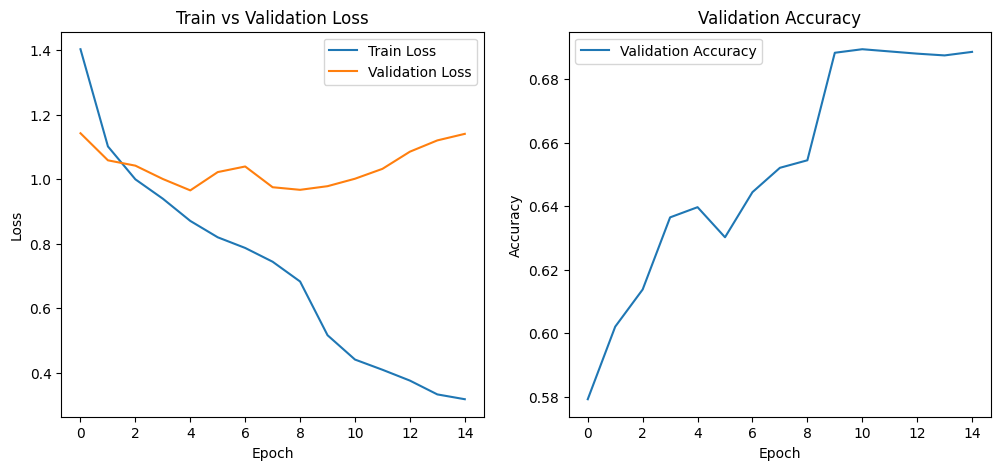

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

class FER2013Dataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = np.fromstring(self.data.iloc[idx, 1], sep=' ', dtype=np.float32).reshape(48, 48)
        image = Image.fromarray(image)
        label = int(self.data.iloc[idx, 0])

        if self.transform:
            image = self.transform(image)

        return image, label


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



csv_file_path = '/content/drive/MyDrive/fer2013.csv'


data = pd.read_csv(csv_file_path)



train_data = data[data['Usage'] == 'Training']
test_data = data[(data['Usage'] == 'PublicTest') | (data['Usage'] == 'PrivateTest')]

train_data.to_csv('/content/fer2013_train.csv', index=False)
test_data.to_csv('/content/fer2013_test.csv', index=False)


train_dataset = FER2013Dataset(csv_file='/content/fer2013_train.csv', transform=transform)
test_dataset = FER2013Dataset(csv_file='/content/fer2013_test.csv', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)





model = resnet18(weights = ResNet18_Weights.DEFAULT) #loading a pretrained ResNet model




num_classes = 7
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)



criterion = nn.CrossEntropyLoss() #loss function
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4) #SGD optimizer

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

def train(model, train_loader, criterion, optimizer, device): #training
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(train_loader.dataset)


def evaluate(model, test_loader, criterion, device): #eval
    model.eval()
    running_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    return running_loss / len(test_loader.dataset), correct / len(test_loader.dataset)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 15

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

# Plotting the training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Validation Loss")

# Plotting validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()


Epoch 1/20, Train Loss: 0.6075, Val Loss: 1.0125, Val Acc: 0.6666
Epoch 2/20, Train Loss: 0.5667, Val Loss: 1.0362, Val Acc: 0.6552
Epoch 3/20, Train Loss: 0.5237, Val Loss: 1.0848, Val Acc: 0.6690
Epoch 4/20, Train Loss: 0.4821, Val Loss: 1.1081, Val Acc: 0.6523
Epoch 5/20, Train Loss: 0.4876, Val Loss: 1.2338, Val Acc: 0.6461
Epoch 6/20, Train Loss: 0.4847, Val Loss: 1.0923, Val Acc: 0.6521
Epoch 7/20, Train Loss: 0.4147, Val Loss: 1.1940, Val Acc: 0.6570
Epoch 8/20, Train Loss: 0.3807, Val Loss: 1.1858, Val Acc: 0.6604
Epoch 9/20, Train Loss: 0.3677, Val Loss: 1.1788, Val Acc: 0.6645
Epoch 10/20, Train Loss: 0.3385, Val Loss: 1.1845, Val Acc: 0.6552
Epoch 11/20, Train Loss: 0.3062, Val Loss: 1.5148, Val Acc: 0.6528


KeyboardInterrupt: 